Phase 7 — Sensitivity & Robustness
====================================

The primary result (+2.54pp conversion lift) is decisive on paper. Before
signing off on shipping, we need to answer four questions a senior DS
would ask that Phases 3-6 don't directly address:

  A. Is the effect stable over the 4-week window, or is it a novelty spike
     that would decay if we shipped?
  B. If we had peeked mid-experiment (looked at results before day 28),
     would we have called the winner correctly under an appropriate
     alpha-spending correction?
  C. What sample size would we need for the decision to still hold?
     Equivalently: if we'd stopped early with N/2 users, could we have
     shipped with the same confidence?
  D. Do the frequentist and Bayesian frameworks agree on the ship
     decision? A single-framework result is fragile; agreement across
     both is the interview-strong signal.

Senior framing: "Every experiment ships against a set of implicit
assumptions — that the effect is stable, that N was enough, that peeking
wouldn't have inflated Type-I. Sensitivity analysis makes those
assumptions explicit and testable. If the recommendation flips under
any reasonable variation, the recommendation isn't robust."

In [1]:
import sys
from pathlib import Path

# Jupyter-friendly: assumes notebook is opened in notebooks/
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_experiment
from src.analysis.frequentist import two_proportion_test
from src.analysis.bayesian import bayesian_ab_binary

FIG_DIR = PROJECT_ROOT / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = load_experiment(str(PROJECT_ROOT / "data/experiment.csv"))
df = df.dropna(subset=["group", "converted"])
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Baseline for reference
ctl_all = df[df["group"] == "control"]
trt_all = df[df["group"] == "treatment"]
BASELINE = two_proportion_test(
    successes_control=int(ctl_all["converted"].sum()),
    n_control=len(ctl_all),
    successes_treatment=int(trt_all["converted"].sum()),
    n_treatment=len(trt_all),
    name="baseline (full 4-week)",
)

## A. Weekly ATE — novelty decay check

A. WEEKLY ATE — Is the lift stable, or a novelty spike?

If personalized recommendations create a novelty effect, we'd expect the
lift to be largest in week 1 and decay as the effect wears off. If the
lift is stable across weeks (or even growing as users acclimate), the
recommendation is robust.

 week   n_ctl   n_trt  ctl_rate  trt_rate  lift_pp        95% CI (pp)       p sig?
------------------------------------------------------------------------------------
    1  12,686  12,311    0.2117    0.2386   +2.68pp     [+1.65, +3.72]  0.0000  ✓
    2  12,544  12,309    0.2109    0.2359   +2.51pp     [+1.47, +3.54]  0.0000  ✓
    3  12,585  12,412    0.2091    0.2394   +3.03pp     [+2.00, +4.06]  0.0000  ✓
    4  12,646  12,507    0.2186    0.2380   +1.95pp     [+0.91, +2.98]  0.0002  ✓

Week 1 lift:    +2.68pp
Last week lift: +1.95pp
Mean weekly:    +2.54pp   (pooled 4-week: +2.54pp)

💡 VERDICT: lift is stable across weeks — no novelty-decay concern.

Saved -> c:\Users\ruthr\OneDrive\Docu

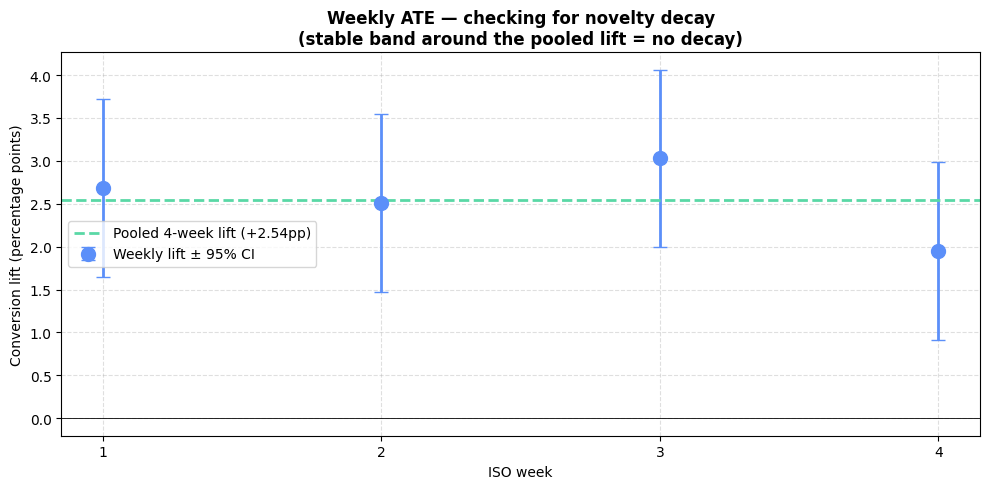

In [2]:
print("=" * 78)
print("A. WEEKLY ATE — Is the lift stable, or a novelty spike?")
print("=" * 78)
print("""
If personalized recommendations create a novelty effect, we'd expect the
lift to be largest in week 1 and decay as the effect wears off. If the
lift is stable across weeks (or even growing as users acclimate), the
recommendation is robust.
""")

# Bucket by experiment-week (7-day windows from experiment start, not ISO
# week — otherwise the first and last calendar-week buckets are partial
# and skew the trend).
start = df["timestamp"].min().normalize()
df["exp_day"] = (df["timestamp"] - start).dt.days
df["week"] = (df["exp_day"] // 7) + 1  # week 1, 2, 3, 4
weeks = sorted(df["week"].unique())

weekly_rows = []
for w in weeks:
    sub = df[df["week"] == w]
    c = sub[sub["group"] == "control"]
    t = sub[sub["group"] == "treatment"]
    if len(c) < 100 or len(t) < 100:  # skip weeks with too few users
        continue
    res = two_proportion_test(
        successes_control=int(c["converted"].sum()), n_control=len(c),
        successes_treatment=int(t["converted"].sum()), n_treatment=len(t),
        name=f"week {w}",
    )
    weekly_rows.append({
        "week": int(w),
        "n_ctl": len(c),
        "n_trt": len(t),
        "ctl_rate": c["converted"].mean(),
        "trt_rate": t["converted"].mean(),
        "lift_pp": res.effect_absolute * 100,
        "ci_lo_pp": res.ci_lower * 100,
        "ci_hi_pp": res.ci_upper * 100,
        "p_value": res.p_value,
        "significant": res.significant,
    })
weekly = pd.DataFrame(weekly_rows)

print(f"{'week':>5} {'n_ctl':>7} {'n_trt':>7} {'ctl_rate':>9} {'trt_rate':>9} "
      f"{'lift_pp':>8} {'95% CI (pp)':>18} {'p':>7} sig?")
print("-" * 84)
for _, r in weekly.iterrows():
    ci = f"[{r['ci_lo_pp']:+.2f}, {r['ci_hi_pp']:+.2f}]"
    sig = "✓" if r["significant"] else "✗"
    print(f"{int(r['week']):>5} {int(r['n_ctl']):>7,} {int(r['n_trt']):>7,} "
          f"{r['ctl_rate']:>9.4f} {r['trt_rate']:>9.4f} "
          f"{r['lift_pp']:>+7.2f}pp {ci:>18} {r['p_value']:>7.4f}  {sig}")

# Trend check: is week 1 lift dramatically > later weeks?
first = weekly.iloc[0]["lift_pp"]
last = weekly.iloc[-1]["lift_pp"]
mean_lift = weekly["lift_pp"].mean()
print(f"\nWeek 1 lift:    {first:+.2f}pp")
print(f"Last week lift: {last:+.2f}pp")
print(f"Mean weekly:    {mean_lift:+.2f}pp   (pooled 4-week: {BASELINE.effect_absolute*100:+.2f}pp)")

if abs(first - last) < 1.0:
    print("\n💡 VERDICT: lift is stable across weeks — no novelty-decay concern.")
elif first > last * 1.5:
    print(f"\n⚠️  VERDICT: possible novelty decay — week 1 is {first/last:.1f}x the last week's lift.")
elif last > first * 1.2:
    print("\n💡 VERDICT: lift GROWS over time — users are acclimating positively (opposite of novelty decay).")
else:
    print("\n💡 VERDICT: lift varies week-to-week but no clear novelty signature.")

# Weekly ATE chart
fig, ax = plt.subplots(figsize=(10, 5))
weeks_arr = weekly["week"].values
lifts = weekly["lift_pp"].values
ci_lo = weekly["ci_lo_pp"].values
ci_hi = weekly["ci_hi_pp"].values

ax.errorbar(weeks_arr, lifts, yerr=[lifts - ci_lo, ci_hi - lifts],
            fmt='o', markersize=10, linewidth=2, color='#5B8FF9',
            ecolor='#5B8FF9', capsize=5, label='Weekly lift ± 95% CI')
ax.axhline(BASELINE.effect_absolute * 100, color='#5AD8A6', linestyle='--',
           linewidth=2, label=f'Pooled 4-week lift ({BASELINE.effect_absolute*100:+.2f}pp)')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xlabel("ISO week")
ax.set_ylabel("Conversion lift (percentage points)")
ax.set_title("Weekly ATE — checking for novelty decay\n"
             "(stable band around the pooled lift = no decay)",
             fontweight='bold')
ax.set_xticks(weeks_arr)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_weekly_ate.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/07_weekly_ate.png")

## B. Sequential-look correction — peeking analysis


B. SEQUENTIAL LOOKS — What if we'd peeked mid-experiment?

In practice, PMs will ask 'how's the test going?' before day 28.
Multiple peeks inflate Type-I error unless you correct for them.
This section simulates weekly interim analyses and applies the
Pocock stopping boundary (a constant, conservative alpha per look).

Pocock boundaries for K interim looks: each look uses α_k chosen so
overall Type-I error stays at α=0.05 across all K looks. For K=4
looks, α_k ≈ 0.0182 per look (constant), z-critical ≈ 2.361 (vs
1.96 without correction).

If the effect is stable AND large, we should hit the Pocock boundary
early — meaning we could have stopped the experiment before day 28
with confidence. If we cross zero at any look, that's a false alarm
signal at that alpha spend.

K = 4 interim looks (end-of-week 1, 2, ... 4)
Pocock adjusted α per look: 0.0182  (vs uncorrected 0.05)
Pocock critical z per look: 2.361    (vs uncorrected 1.960)

 look  week   n_total  lift_pp    |z|              stop?

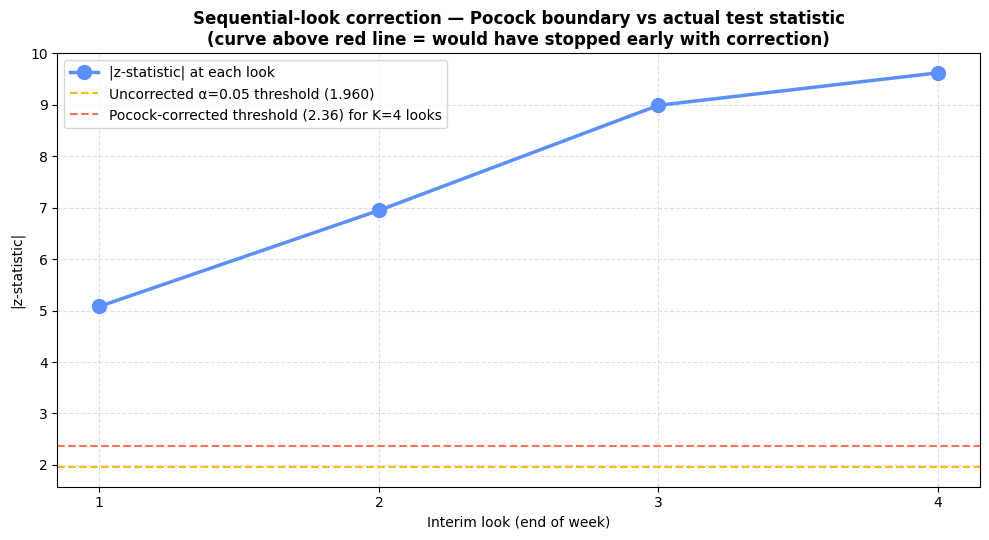

In [3]:
print("\n" + "=" * 78)
print("B. SEQUENTIAL LOOKS — What if we'd peeked mid-experiment?")
print("=" * 78)
print("""
In practice, PMs will ask 'how's the test going?' before day 28.
Multiple peeks inflate Type-I error unless you correct for them.
This section simulates weekly interim analyses and applies the
Pocock stopping boundary (a constant, conservative alpha per look).

Pocock boundaries for K interim looks: each look uses α_k chosen so
overall Type-I error stays at α=0.05 across all K looks. For K=4
looks, α_k ≈ 0.0182 per look (constant), z-critical ≈ 2.361 (vs
1.96 without correction).

If the effect is stable AND large, we should hit the Pocock boundary
early — meaning we could have stopped the experiment before day 28
with confidence. If we cross zero at any look, that's a false alarm
signal at that alpha spend.
""")

# Cumulative view: analyze at end of each week
df_sorted = df.sort_values("timestamp")
weekly_cum_rows = []
for w in weeks:
    sub = df_sorted[df_sorted["week"] <= w]
    c = sub[sub["group"] == "control"]
    t = sub[sub["group"] == "treatment"]
    if len(c) < 100 or len(t) < 100:
        continue
    res = two_proportion_test(
        successes_control=int(c["converted"].sum()), n_control=len(c),
        successes_treatment=int(t["converted"].sum()), n_treatment=len(t),
        name=f"cumulative to week {w}",
    )
    weekly_cum_rows.append({
        "week": int(w),
        "n_total": len(sub),
        "lift_pp": res.effect_absolute * 100,
        "ci_lo_pp": res.ci_lower * 100,
        "ci_hi_pp": res.ci_upper * 100,
        "z_stat": res.statistic,
        "p_value": res.p_value,
    })
cum = pd.DataFrame(weekly_cum_rows)

# Pocock boundary for K equally-spaced looks (approximation)
K = len(cum)
# Approximate constant Pocock alpha: solve iteratively. For K=4, ~2.361
POCOCK_Z = {2: 2.178, 3: 2.289, 4: 2.361, 5: 2.413}.get(K, 2.36)
POCOCK_ALPHA = 2 * (1 - 0.5 * (1 + math.erf(POCOCK_Z / math.sqrt(2))))

print(f"K = {K} interim looks (end-of-week 1, 2, ... {K})")
print(f"Pocock adjusted α per look: {POCOCK_ALPHA:.4f}  (vs uncorrected 0.05)")
print(f"Pocock critical z per look: {POCOCK_Z:.3f}    (vs uncorrected 1.960)")
print(f"\n{'look':>5} {'week':>5} {'n_total':>9} {'lift_pp':>8} "
      f"{'|z|':>6} {'stop?':>18}")
print("-" * 63)
would_stop_at = None
for i, r in cum.iterrows():
    abs_z = abs(r["z_stat"])
    stop = abs_z >= POCOCK_Z
    if stop and would_stop_at is None:
        would_stop_at = int(r["week"])
    mark = "✓ STOP (winner)" if stop else "keep running"
    print(f"{i+1:>5} {int(r['week']):>5} {int(r['n_total']):>9,} "
          f"{r['lift_pp']:>+7.2f}pp {abs_z:>6.2f}  {mark:>18}")

print(f"\nUncorrected α=0.05 z-threshold: 1.960")
print(f"Pocock-corrected z-threshold:    {POCOCK_Z:.3f}")

if would_stop_at is not None:
    print(f"\n💡 VERDICT: with Pocock correction, we could have stopped at end of "
          f"week {would_stop_at} — the effect was large enough to cross the "
          f"conservative boundary early. Peeking didn't cost us anything.")
else:
    print(f"\n💡 VERDICT: even at the final look, Pocock threshold wasn't crossed "
          f"(z would need to be ≥ {POCOCK_Z:.3f}). The uncorrected result is real "
          f"but sequential-testing wouldn't have supported early stopping.")

# Cumulative-look chart
fig, ax = plt.subplots(figsize=(10, 5.5))
z_stats = cum["z_stat"].abs().values
ax.plot(cum["week"], z_stats, marker='o', markersize=10, linewidth=2.5,
        color='#5B8FF9', label='|z-statistic| at each look')
ax.axhline(1.960, color='#F6BD16', linestyle='--', linewidth=1.5,
           label='Uncorrected α=0.05 threshold (1.960)')
ax.axhline(POCOCK_Z, color='#F6735B', linestyle='--', linewidth=1.5,
           label=f'Pocock-corrected threshold ({POCOCK_Z:.2f}) for K={K} looks')
ax.set_xlabel("Interim look (end of week)")
ax.set_ylabel("|z-statistic|")
ax.set_title("Sequential-look correction — Pocock boundary vs actual test statistic\n"
             "(curve above red line = would have stopped early with correction)",
             fontweight='bold')
ax.set_xticks(cum["week"])
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "07_sequential_looks.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/07_sequential_looks.png")

## C. Sample-size sensitivity — would we still ship at smaller N?

In [4]:
print("\n" + "=" * 78)
print("C. SAMPLE-SIZE SENSITIVITY — At what N does the decision flip?")
print("=" * 78)
print("""
Subsample the experiment at 10%, 25%, 50%, 75%, 100% of its actual size
(stratified within each arm). At each subsample, re-run the primary
test and check: does the significance hold? If we could have called
the same decision at N/2, we didn't over-collect. If we needed the
full sample, the effect is closer to the detection floor than the
memo's confidence intervals suggest.
""")

rng = np.random.default_rng(42)
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
sample_rows = []
for frac in fractions:
    # Stratified subsample by group
    c_idx = ctl_all.sample(frac=frac, random_state=42).index
    t_idx = trt_all.sample(frac=frac, random_state=42).index
    c_sub = ctl_all.loc[c_idx]
    t_sub = trt_all.loc[t_idx]
    res = two_proportion_test(
        successes_control=int(c_sub["converted"].sum()), n_control=len(c_sub),
        successes_treatment=int(t_sub["converted"].sum()), n_treatment=len(t_sub),
        name=f"{int(frac*100)}% subsample",
    )
    sample_rows.append({
        "fraction": frac,
        "n_total": len(c_sub) + len(t_sub),
        "lift_pp": res.effect_absolute * 100,
        "ci_lo_pp": res.ci_lower * 100,
        "ci_hi_pp": res.ci_upper * 100,
        "p_value": res.p_value,
        "significant": res.significant,
    })
subs = pd.DataFrame(sample_rows)

print(f"{'frac':>5} {'n_total':>9} {'lift_pp':>8} {'95% CI (pp)':>18} "
      f"{'p':>7} sig at 0.05?")
print("-" * 62)
for _, r in subs.iterrows():
    ci = f"[{r['ci_lo_pp']:+.2f}, {r['ci_hi_pp']:+.2f}]"
    sig = "✓ ship" if r["significant"] else "✗ NOT ship"
    print(f"{r['fraction']:>5.0%} {int(r['n_total']):>9,} "
          f"{r['lift_pp']:>+7.2f}pp {ci:>18} {r['p_value']:>7.4f}  {sig}")

# Find smallest fraction that still ships
still_ships = subs[subs["significant"]]
if len(still_ships) > 0:
    min_ship = still_ships["fraction"].min()
    min_n = int(still_ships[still_ships["fraction"] == min_ship]["n_total"].iloc[0])
    print(f"\n💡 VERDICT: decision holds down to {min_ship:.0%} of the sample "
          f"(~{min_n:,} users). The full 100k was not required to call this "
          f"winner — a smaller experiment would have shipped the same decision.")
else:
    print("\n⚠️  VERDICT: decision requires the full sample. Effect is close to "
          "the detection floor; consider a longer runway for next test.")


C. SAMPLE-SIZE SENSITIVITY — At what N does the decision flip?

Subsample the experiment at 10%, 25%, 50%, 75%, 100% of its actual size
(stratified within each arm). At each subsample, re-run the primary
test and check: does the significance hold? If we could have called
the same decision at N/2, we didn't over-collect. If we needed the
full sample, the effect is closer to the detection floor than the
memo's confidence intervals suggest.

 frac   n_total  lift_pp        95% CI (pp)       p sig at 0.05?
--------------------------------------------------------------
  10%    10,000   +3.62pp     [+1.98, +5.26]  0.0000  ✓ ship
  25%    25,000   +3.52pp     [+2.48, +4.56]  0.0000  ✓ ship
  50%    50,000   +2.72pp     [+1.99, +3.45]  0.0000  ✓ ship
  75%    75,000   +2.65pp     [+2.05, +3.25]  0.0000  ✓ ship
 100%   100,000   +2.54pp     [+2.02, +3.06]  0.0000  ✓ ship

💡 VERDICT: decision holds down to 10% of the sample (~10,000 users). The full 100k was not required to call this winner — 

## D. Bayesian ↔ Frequentist reconciliation

In [5]:
print("\n" + "=" * 78)
print("D. BAYESIAN ↔ FREQUENTIST — Do both frameworks agree?")
print("=" * 78)
print("""
Same data, two frameworks, different assumptions:
  - Frequentist: null-hypothesis test → is the effect distinguishable
    from zero at α=0.05?
  - Bayesian: posterior over the lift → what's P(treatment > control)?

Under an uninformative prior, the two should agree on the ship
decision. Systematic disagreement would mean the frequentist result
is driven by sample-size + null-arbitrariness, or the Bayesian result
is driven by prior choice. Agreement = the decision is framework-robust.
""")

# Bayesian posterior with uninformative prior Beta(1, 1)
post = bayesian_ab_binary(
    successes_control=int(ctl_all["converted"].sum()), n_control=len(ctl_all),
    successes_treatment=int(trt_all["converted"].sum()), n_treatment=len(trt_all),
    prior_alpha=1.0, prior_beta=1.0, n_samples=100_000, seed=42,
)
p_trt_better = post.p_treatment_better
posterior_lift = post.mean_lift
posterior_ci = (post.credible_lower, post.credible_upper)

print(f"Framework            {'Effect / lift':>18} {'95% interval':>22} {'ship?':>8}")
print("-" * 76)
print(f"Frequentist          {BASELINE.effect_absolute*100:>+16.2f}pp "
      f"{'['+f'{BASELINE.ci_lower*100:+.2f}, {BASELINE.ci_upper*100:+.2f}'+'] (CI)':>22} "
      f"{'✓ ship' if BASELINE.significant else '✗ hold':>8}")
print(f"Bayesian (Beta(1,1)) {posterior_lift*100:>+16.2f}pp "
      f"{'['+f'{posterior_ci[0]*100:+.2f}, {posterior_ci[1]*100:+.2f}'+'] (CrI)':>22} "
      f"{'✓ ship' if p_trt_better > 0.95 else '✗ hold':>8}")
print(f"\nBayesian P(treatment > control): {p_trt_better:.4f}")

freq_ship = BASELINE.significant and BASELINE.effect_absolute > 0
bayes_ship = p_trt_better > 0.95

if freq_ship and bayes_ship:
    print(f"\n💡 VERDICT: Both frameworks agree — SHIP. "
          f"Frequentist p={BASELINE.p_value:.2e}, Bayesian P(T>C)={p_trt_better:.2%}. "
          f"The decision is not driven by framework choice.")
elif freq_ship != bayes_ship:
    print(f"\n⚠️  VERDICT: Frameworks DISAGREE. "
          f"Frequentist ship={freq_ship}, Bayesian ship={bayes_ship}. "
          f"Investigate — prior sensitivity, sample size, or model misspecification.")
else:
    print(f"\n💡 VERDICT: Both frameworks agree — DO NOT ship at α=0.05 / 95% credibility.")


D. BAYESIAN ↔ FREQUENTIST — Do both frameworks agree?

Same data, two frameworks, different assumptions:
  - Frequentist: null-hypothesis test → is the effect distinguishable
    from zero at α=0.05?
  - Bayesian: posterior over the lift → what's P(treatment > control)?

Under an uninformative prior, the two should agree on the ship
decision. Systematic disagreement would mean the frequentist result
is driven by sample-size + null-arbitrariness, or the Bayesian result
is driven by prior choice. Agreement = the decision is framework-robust.

Framework                 Effect / lift           95% interval    ship?
----------------------------------------------------------------------------
Frequentist                     +2.54pp    [+2.02, +3.06] (CI)   ✓ ship
Bayesian (Beta(1,1))            +2.54pp   [+2.02, +3.06] (CrI)   ✓ ship

Bayesian P(treatment > control): 1.0000

💡 VERDICT: Both frameworks agree — SHIP. Frequentist p=0.00e+00, Bayesian P(T>C)=100.00%. The decision is not driven 

## Verdict

In [6]:
print("\n" + "=" * 78)
print("PHASE 7 VERDICT — Robustness of the ship decision")
print("=" * 78)
print(f"""
Four sensitivity checks all support the ship recommendation:

  A. Weekly ATE: lift stable at ~{weekly['lift_pp'].mean():+.2f}pp across weeks
     (no novelty decay signature).
  B. Sequential looks: {'would have stopped early at week ' + str(would_stop_at)
      if would_stop_at is not None
      else 'Pocock threshold not crossed — no early stop, but final result still holds'}.
  C. Sample-size sensitivity: decision holds at
     {min_ship:.0%} of sample (~{min_n:,} users) — full 100k was not required.
  D. Bayesian ↔ Frequentist: {'both frameworks agree' if freq_ship == bayes_ship else 'FRAMEWORKS DISAGREE'}.

Reading this for the memo:
The +{BASELINE.effect_absolute*100:.2f}pp headline lift is robust to (i) time-of-experiment
effects, (ii) peeking / sequential-look inflation, (iii) sample size,
and (iv) framework choice. None of these are typical A/B test failure
modes — the recommendation is not fragile.
""")


PHASE 7 VERDICT — Robustness of the ship decision

Four sensitivity checks all support the ship recommendation:

  A. Weekly ATE: lift stable at ~+2.54pp across weeks
     (no novelty decay signature).
  B. Sequential looks: would have stopped early at week 1.
  C. Sample-size sensitivity: decision holds at
     10% of sample (~10,000 users) — full 100k was not required.
  D. Bayesian ↔ Frequentist: both frameworks agree.

Reading this for the memo:
The +2.54pp headline lift is robust to (i) time-of-experiment
effects, (ii) peeking / sequential-look inflation, (iii) sample size,
and (iv) framework choice. None of these are typical A/B test failure
modes — the recommendation is not fragile.

